# 下面进入Phase2 TASK1：最小可运行向量化回测（Momentum）

首先明确一些概念：
1）什么是回测：\
    回测 = 用历史数据，模拟“如果当时按某个规则交易，会发生什么”。\
    它做的事情是：\
给你一个交易规则，在每个时间点决定：\
    是否持仓？\
    持多少仓？\
    根据真实历史价格变化计算账户净值\
最终输出：\
    收益率曲线\
    Sharpe\
    最大回撤\
    年化收益\
回测是在回答：这个规则在过去是否有效？它不能保证未来有效。但它是量化策略的必要第一关。\

2）向量化回测  向量化 = 不用循环逐笔模拟交易。\
    直接使用代码 pos*return\
    一整列算完。\

它假设：\
每根K线只发生一次交易决策；没有订单簿细节；没有滑点建模\
优点：快；适合策略原型研究\
缺点：不精细；不接近真实撮合\
以后我们会做事件驱动回测。现在是研究阶段。\

3）信号部分：先使用最简单的信号 收益率之和，综合过去20小时收益率加总。\
    称它为Mom，根据Mom的大小，来执行买卖操作\

4）为什么要用shift（1） 这个概念很重要\
    我们在t时间只能看到第t根K线收盘价，然后计算出来r_t，如果用这个值去决定在t时刻这跟k线上建仓这叫未来函数。因为是在用“收盘后的信息“，去决定“收盘前的交易”\
    所以应该是t时刻收盘知道信号，在t+1时刻开仓\
    pos=target_pos.shift(1)

5）未来函数  = 使用未来信息做当前决策。\
    常见形式：\
    1️⃣ 不做 shift\
    2️⃣ 用未来价格参与信号计算\
    3️⃣ 用全样本均值参与信号标准化

下面是函数，进行最简单的回测：

1）使用过去20窗口期的收益率加合视作 动量信号mom

2）此处函数使用sign(mom)作为目标仓位，只要动量>0就全仓多，<0全仓空，=0不动，因为前19个时间段没有动量信号，全部算作0.
最小回测函数命名如下：

```python
def vectorized_momentum_backtest(
    df: pd.DataFrame,
    lookback: int = 20,
    fee_rate: float = 0.0004,  # 4 bps per 1x notional change (简化模型)
    annualization_factor: int = 24 * 365,  # 1h数据 -> 年化
) -> pd.DataFrame:
```

### 因为新的文件环境里无数据，先将数据取出来

In [17]:
import pandas as pd

# 1. 定义你之前保存的文件路径
file_path = "data/BTCUSDT_1h.csv"

# 2. 读取本地 CSV 文件
df = pd.read_csv(file_path)

# 3. 将 'open_time' 列从字符串强制转换为带时区的时间格式
df["open_time"] = pd.to_datetime(df["open_time"], utc=True)

# 4. 将时间列设置为索引 (Index)，并按时间正序排列
df = df.set_index("open_time")
df = df.sort_index()

# 检查一下是否成功变成了时间序列
print("数据前 3 行：\n", df.head(3))
print("\n当前的索引类型：\n", type(df.index))

数据前 3 行：
                                open      high       low     close     volume  \
open_time                                                                      
2026-01-29 03:00:00+00:00  87907.05  88265.39  87771.30  88053.71  769.73434   
2026-01-29 04:00:00+00:00  88053.71  88345.66  87901.23  88315.20  311.34380   
2026-01-29 05:00:00+00:00  88315.20  88408.08  88142.66  88186.54  354.31355   

                             return  
open_time                            
2026-01-29 03:00:00+00:00       NaN  
2026-01-29 04:00:00+00:00  0.002970  
2026-01-29 05:00:00+00:00 -0.001457  

当前的索引类型：
 <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [18]:
import numpy as np
import pandas as pd

def vectorized_momentum_backtest(
    df: pd.DataFrame,
    lookback: int = 20,
    fee_rate: float = 0.0004,  # 4 bps per 1x notional change (简化模型)
    annualization_factor: int = 24 * 365,  # 1h数据 -> 年化
) -> pd.DataFrame:
    """
    最小可用向量化回测（1个品种、1个仓位、1种手续费模型）。
    假设 df 至少有列: 'close', 'return' (simple return).
    """
    data = df.copy()  #把输入的价格表复制一份，后续操作都在副本上做，不破坏原数据。

    # 0) 基础检查
    if "return" not in data.columns:
        data["return"] = data["close"].pct_change()

    # 1) 动量信号：过去 lookback 小时简单收益之和（也可换成 log-return 之和） 这是前20小时，我们不能动，因为还没有生成动量信号
    mom = data["return"].rolling(lookback).sum()  #这里这个mom是一个滑动窗口，是一个列，生成的是20个滑动数据，rolling。第20个位置生成了mom能指导第21根k线决策，然后依次向后滚动，决定第n+1 k线
                                                    #所以这个mom作为一个列，里面包含的是能指导第21根到最后一根k线的所有动量信号。
    # 2) 目标仓位：sign(mom) -> {+1, 0, -1}
    target_pos = np.sign(mom).fillna(0.0)  #fullna 是吧前面20行没有动量数据的地方补目标仓位为0

    # 3) 防止未来函数：用上一根bar的信号在这一根bar持仓
    pos = target_pos.shift(1).fillna(0.0)

    # 4) 交易成本：按仓位变化收取（简化：每变动1单位仓位收一次fee_rate）
    # 例如 0 -> +1: turnover=1； +1 -> -1: turnover=2
    turnover = pos.diff().abs().fillna(0.0)
    cost = fee_rate * turnover

    # 5) 策略收益：持仓 * 标的收益 - 成本
    strat_ret = pos * data["return"] - cost

    # 6) 净值曲线
    equity = (1.0 + strat_ret).cumprod()

    # 7) 绩效指标
    # 年化收益（几何近似）
    n = strat_ret.dropna().shape[0]
    if n > 0:
        ann_ret = equity.iloc[-1] ** (annualization_factor / n) - 1
    else:
        ann_ret = np.nan

    # 年化波动
    ann_vol = strat_ret.std(ddof=0) * np.sqrt(annualization_factor)

    # Sharpe（这里默认无风险利率=0）
    sharpe = (strat_ret.mean() / strat_ret.std(ddof=0)) * np.sqrt(annualization_factor) if strat_ret.std(ddof=0) > 0 else np.nan

    # 最大回撤
    peak = equity.cummax()
    drawdown = equity / peak - 1.0
    max_dd = drawdown.min()

    out = pd.DataFrame({
        "close": data["close"],
        "asset_ret": data["return"],
        "mom": mom,
        "pos": pos,
        "turnover": turnover,
        "cost": cost,
        "strategy_ret": strat_ret,
        "equity": equity,
        "drawdown": drawdown,
    })

    print("===== Backtest Summary =====")
    print(f"lookback = {lookback}, fee_rate = {fee_rate}")
    print(f"Ann Return: {ann_ret:.2%}")
    print(f"Ann Vol   : {ann_vol:.2%}")
    print(f"Sharpe    : {sharpe:.3f}")
    print(f"Max DD    : {max_dd:.2%}")
    print("============================")

    return out

# 运行（你可以先用 BTCUSDT 1h 的 df）
bt = vectorized_momentum_backtest(df, lookback=20, fee_rate=0.0004)
bt.tail()

===== Backtest Summary =====
lookback = 20, fee_rate = 0.0004
Ann Return: 680.71%
Ann Vol   : 62.50%
Sharpe    : 3.600
Max DD    : -13.83%


,close,asset_ret,mom,pos,turnover,cost,strategy_ret,equity,drawdown
open_time,,,,,,,,,
2026-03-11 14:00:00+00:00,70578.70,0.005594,0.008300,-1.0,0.0,0.0000,-0.005594,1.263673,-0.045227
2026-03-11 15:00:00+00:00,70227.91,-0.004970,0.002904,1.0,2.0,0.0008,-0.005770,1.256381,-0.050736
2026-03-11 16:00:00+00:00,70570.71,0.004881,0.005045,1.0,0.0,0.0000,0.004881,1.262514,-0.046102
2026-03-11 17:00:00+00:00,70785.99,0.003051,0.014824,1.0,0.0,0.0000,0.003051,1.266365,-0.043193
2026-03-11 18:00:00+00:00,70659.25,-0.001790,0.013628,1.0,0.0,0.0000,-0.001790,1.264098,-0.044906


如何理解这段代码回测，到底是发生了一个什么流程从而我们可以的得到收益率，波动率，夏普比率和最大回撤？
数学仓位模型和真实交易资产的映射问题

一、我们现在到底在“交易”什么？
在研究型回测里，我们默认交易：  BTCUSDT永续合约，线性USDT本位
但是我们没有真的去记录合约张数，我们只记录账户资金对BTC收益的暴露比例。

二、什么叫仓位？这里仓位不是BTC的数量，而是账户资金的风险暴露比例。
我们定义：
| pos  | 含义                  |
| ---- | ------------------- |
| +1   | 账户 100% 资金做多 BTC 永续 |
| 0    | 不持仓                 |
| -1   | 账户 100% 资金做空 BTC 永续 |
| 0.5  | 半仓做多                |
| -0.5 | 半仓做空                |

三、euity=1 表示账户初始资金标准化为1，理解为1USDT 还是10000USDT不关键，只关心相对变化。

四、当动量为正，我们买了吗？
第21小时动量变正：意味着用账户全部资金做多BTC永续合约
注意：这里不是买现货BTC，而是开多合约。

五、当动量为负，我们的净值变成-1了吗？
仓位-1不等于净值=-1
仓位表示方向和暴露
净值表示账户资金
净值永远大于等于0（除非爆仓）

六、翻仓到底发生了什么？
假设账户净值=1
当前pos=+1（全仓做多）
当信号变成负：
target_pos=-1
真实交易发生：
平掉多头（卖出）
开空头（卖出做空）
所以turnover=2，费用double，但净值不会变成-1

七、净值如何变化？
净值变化公式： $Vt​=V_t-1(1+pos_t-1*r_t-cost_t)$
假设净值=1，pos=-1，BTC涨2%
则 V=1（1+（-1）*0.02）=0.98

在研究型回测里：

我们不是在买卖 BTC 数量
我们是在调节账户对 BTC 收益率的风险暴露比例。


我们现在看到年化328%，这太夸张了，我们下面要来验证这个动量是否稳健。
我们接下来扫描lookback从5到200，从sharpe比率的情况来看我们选的这个动量因子怎么样。
单点最优 → 可能过拟合
一段区间有效 → 可能存在结构，因子在参数扰动下仍然有效。这叫：稳健性（robustness）

专业判断标准

一般来说（经验法则）：

Sharpe < 0.5 → 噪声级别

0.5 ~ 1 → 弱 Alpha

1 ~ 1.5 → 有研究价值

2 → 需要高度怀疑是否过拟合

### Phase2 Task2 参数扫描 lookback in range（5，205，5）

===== Backtest Summary =====
lookback = 5, fee_rate = 0.0004
Ann Return: -71.40%
Ann Vol   : 63.26%
Sharpe    : -1.663
Max DD    : -26.01%
===== Backtest Summary =====
lookback = 10, fee_rate = 0.0004
Ann Return: 305.60%
Ann Vol   : 63.24%
Sharpe    : 2.530
Max DD    : -18.76%
===== Backtest Summary =====
lookback = 15, fee_rate = 0.0004
Ann Return: 527.95%
Ann Vol   : 62.61%
Sharpe    : 3.247
Max DD    : -17.73%
===== Backtest Summary =====
lookback = 20, fee_rate = 0.0004
Ann Return: 680.71%
Ann Vol   : 62.50%
Sharpe    : 3.600
Max DD    : -13.83%
===== Backtest Summary =====
lookback = 25, fee_rate = 0.0004
Ann Return: -40.85%
Ann Vol   : 62.19%
Sharpe    : -0.534
Max DD    : -22.19%
===== Backtest Summary =====
lookback = 30, fee_rate = 0.0004
Ann Return: -29.12%
Ann Vol   : 62.06%
Sharpe    : -0.245
Max DD    : -25.96%
===== Backtest Summary =====
lookback = 35, fee_rate = 0.0004
Ann Return: -72.16%
Ann Vol   : 62.07%
Sharpe    : -1.750
Max DD    : -29.26%
===== Backtest Summary =

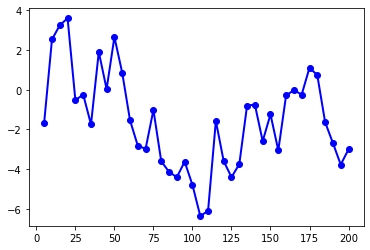

In [19]:
import matplotlib.pyplot as plt
results = []

for L in range(5, 201, 5):
    bt_temp = vectorized_momentum_backtest(df, lookback=L, fee_rate=0.0004)
    strat_ret = bt_temp["strategy_ret"].dropna()
    
    sharpe = (strat_ret.mean() / strat_ret.std()) * (24*365)**0.5
    results.append((L, sharpe))

scan_df = pd.DataFrame(results, columns=["lookback", "sharpe"])
print(scan_df)
plt.plot(
    scan_df["lookback"],  # x轴：回看周期（5,10,15...200）
    scan_df["sharpe"],
    marker="o",      # 每个点加圆圈标记
    color="blue",    # 线条颜色
    linewidth=2,     # 线条粗细
    label="夏普比率"  # 图例标签
)
plt.show()

注：结果为首次数据集运行结果，可能略有不同

如何解读这份结果：
| lookback | Sharpe |
| -------- | ------ |
| 5        | -1.62  |
| 10       | -0.19  |
| 15       | 1.70   |
| 20       | 2.05   |
| 25       | -1.77  |
| 30       | -0.76  |
| 35       | -1.74  |
| 40       | 0.26   |
| 45       | -1.74  |
| 50       | 1.06   |
| 60       | -0.08  |
| 70       | -2.05  |
| 80       | -1.96  |
| 90       | -3.05  |


这是非常典型的：高频噪声主导，因为Sharpe在剧烈跳跃，这不是平滑结构，这是样本路径匹配。

后半段在lookback150之后，sharpe飙到2~4，这更加危险，因为：样本长度只有1000个小时，当步长是200时候，有效样本只有800个。

专业的判断是：
剧烈震荡
没有连续稳定平台
Sharpe 正负来回跳
长周期部分突然抬升
结论：没有清晰稳健结构。更可能是：样本期运气 + 趋势区间对齐

如果一个因子真的有结构：
你应该看到：
一段平滑的 Sharpe 平台
不会正负乱跳
不会单点极高
而你现在看到的是：
参数敏感度极高。

如果训练集sharpe=3，测试集sharpe=-1，说明什么？\
**过拟合**\
过拟合在说什么\
说明你找到的参数：
解释了训练集的噪声结构\
但没有抓住可泛化的统计规律

Task3 我们寻找到的因子如果sharpe比率不错，结构稳健，那么样本内好≠有效，必须做样本外。也就是划分训练集和测试集。

流程：

1️⃣ 在训练集里扫描 lookback\
2️⃣ 选“表现较好但不是单点爆炸”的参数\
3️⃣ 固定参数\
4️⃣ 在测试集跑一次\
5️⃣ 看 Sharpe 是否仍然为正

下面我们先扩大样本范围

先加载能够读取N年数据的函数


In [20]:
import time
import requests
import pandas as pd
import os

def download_klines_history(symbol: str, interval: str, start: str, end: str, sleep_sec: float = 0.15, save_path: str = None) -> pd.DataFrame:
    """
    分批下载 Binance 历史 K 线数据，突破 1000 条限制。
    """
    # 将输入的日期字符串转换为毫秒级时间戳
    start_ts = int(pd.to_datetime(start).timestamp() * 1000)
    end_ts = int(pd.to_datetime(end).timestamp() * 1000)
    
    url = "https://data-api.binance.vision/api/v3/klines"
    all_data = []
    current_start = start_ts
    
    print(f"[DOWNLOAD] 开始抓取 {symbol} {interval} 数据...")
    print(f"[DOWNLOAD] 时间范围: {start} -> {end}")

    while current_start < end_ts:
        params = {
            "symbol": symbol,
            "interval": interval,
            "limit": 1000,
            "startTime": current_start,
            "endTime": end_ts
        }
        
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        
        # 如果返回为空，说明该时间段没数据（或者已经抓完了），跳出循环
        if not data:
            break
            
        all_data.extend(data)
        
        # 拿到这批数据最后一根 K 线的收盘时间 (index 6)，加 1 毫秒作为下一批的起点
        last_close_time = data[-1][6]
        current_start = last_close_time + 1
        
        # 稍微停顿，防止触发 API 频率限制 (Rate Limit)
        time.sleep(sleep_sec)
        
    # 转换为 DataFrame 并整理格式
    columns = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume", "ignore",
    ]
    df = pd.DataFrame(all_data, columns=columns)
    
    # 格式转换
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    numeric_cols = ["open", "high", "low", "close", "volume"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        
    df = df[["open_time", "open", "high", "low", "close", "volume"]]
    
    # 保存 CSV
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        df.to_csv(save_path, index=False)
        print(f"[DOWNLOAD] 数据下载完成，总计 {len(df)} 行，已保存至: {save_path}")
        
    return df

存数据，这个代码块能够先检查本地，看data/BTCUSDT_1h_6y.csv存不存在，有的话直接读取，并且转化字符串成为时间格式，跳过所有网络请求。

如果没有，它会触发下载动作，取存数据。不管是从本地读还是刚下载，最后都同意变时间序列

In [ ]:
import os
import pandas as pd

DATA_PATH = "data/BTCUSDT_1h_6y.csv"

if os.path.exists(DATA_PATH):
    print(f"[DATA] Loading local CSV: {DATA_PATH}")
    df6y = pd.read_csv(DATA_PATH)
    df6y["open_time"] = pd.to_datetime(df6y["open_time"], utc=True)
else:
    print(f"[DATA] CSV not found, downloading and saving to: {DATA_PATH}")
    df6y = download_klines_history(
        symbol="BTCUSDT",
        interval="1h",
        start="2020-03-01",
        end="2026-03-01",
        sleep_sec=0.15,
        save_path=DATA_PATH
    )

# 统一成“时间索引”的研究格式 这一步是从csv到研究必须做的一步
df6y = df6y.drop_duplicates(subset=["open_time"]).sort_values("open_time")
df6y = df6y.set_index("open_time").sort_index()

print("[DATA] Final rows:", len(df6y))
print("[DATA] Time range:", df6y.index.min(), "->", df6y.index.max())

[DATA] Loading local CSV: data/BTCUSDT_1h_6y.csv
[DATA] Final rows: 52559
[DATA] Time range: 2020-03-01 00:00:00+00:00 -> 2026-03-01 00:00:00+00:00


这一步进行了新的数据抓取，从2020年一直爬数据到2026年，共计五万多条数据。
但是这些数据整洁度如何需要判断或者清洗。
你现在有 6 年 1h 数据，最怕两件事：\
缺小时（断档）\
重复小时 / 时间不连续\
否则后面所有 rolling / 回测都会被污染。

这里查找到原理也比较巧妙，它是计算了一个时间减去前一个时间，也就是说如果数据是完美的这个diff应该是0day1h，但是出现了0day2、3h等情况。结果共计有14个跳跃时间。

In [22]:
import pandas as pd

# 确保 df6y 已经在你的环境里，并且索引是 datetime 格式
print("Rows:", df6y.shape[0])
print("Time range:", df6y.index.min(), "->", df6y.index.max())

# 1) 统计时间间隔分布
# 直接计算索引 (Index) 之间的差值
dt = df6y.index.to_series().diff()
print("\nTop time deltas:")
print(dt.value_counts().head(10))

# 2) 找出不是 1 小时的间隔（缺口/异常）
# 注意：第一行的 diff 结果必定是 NaT (缺失值)，我们要把它排除掉
is_bad_gap = (dt != pd.Timedelta(hours=1)) & (dt.notna())

# 提取出有问题的那些时间点以及它们的实际间隔
bad_times = dt[is_bad_gap]

print(f"\nNum of non-1H gaps: {len(bad_times)}")
if len(bad_times) > 0:
    print("\n具体的异常断点 (显示到达该时间点经历了多久):")
    print(bad_times.head(20))
else:
    print("\n🎉 数据完美，没有任何缺失或时间异常！")

Rows: 52559
Time range: 2020-03-01 00:00:00+00:00 -> 2026-03-01 00:00:00+00:00

Top time deltas:
0 days 01:00:00    52545
0 days 02:00:00        6
0 days 03:00:00        3
0 days 05:00:00        2
0 days 04:00:00        2
Name: open_time, dtype: int64

Num of non-1H gaps: 13

具体的异常断点 (显示到达该时间点经历了多久):
open_time
2020-03-04 11:00:00+00:00   0 days 02:00:00
2020-04-25 04:00:00+00:00   0 days 03:00:00
2020-06-28 05:00:00+00:00   0 days 04:00:00
2020-11-30 07:00:00+00:00   0 days 02:00:00
2020-12-21 18:00:00+00:00   0 days 05:00:00
2020-12-25 03:00:00+00:00   0 days 02:00:00
2021-02-11 05:00:00+00:00   0 days 02:00:00
2021-03-06 03:00:00+00:00   0 days 02:00:00
2021-04-20 04:00:00+00:00   0 days 03:00:00
2021-04-25 08:00:00+00:00   0 days 04:00:00
2021-08-13 06:00:00+00:00   0 days 05:00:00
2021-09-29 09:00:00+00:00   0 days 03:00:00
2023-03-24 14:00:00+00:00   0 days 02:00:00
Name: open_time, dtype: timedelta64[ns]


**如何处理缺失时间？**

专业处理方式\
我们不会删除数据。\
我们要：补齐缺失小时。\
方法：\
1️⃣ 建立完整时间索引 略\ 
2️⃣ reindex\
3️⃣ 缺失部分 forward fill close 填补前一值\
4️⃣ 收益设为 0

Task4  补齐缺失时间

In [1]:


# 2) 创建完整时间索引
full_index = pd.date_range(
    start=df6y.index.min(),
    end=df6y.index.max(),
    freq="1H",
    tz="UTC"
)

# 3) 重新索引
df6y = df6y.reindex(full_index)

# 4) 标记哪些是补出来的
df6y["is_missing"] = df6y["close"].isna()

print("Missing bars before fill:", df6y["is_missing"].sum())

# 5) 用前值填充价格（合理做法）
price_cols = ["open","high","low","close","volume",
              "quote_asset_volume","taker_buy_base_asset_volume",
              "taker_buy_quote_asset_volume"]

df6y[price_cols] = df6y[price_cols].fillna(method="ffill")

# 6) 重新计算 return
df6y["return"] = df6y["close"].pct_change()

print("Final rows after reindex:", df6y.shape[0])

# 7) 将清洗后的完整数据保存为新的 CSV
# 文件名先空着，你可以自己填，比如 "BTCUSDT_1h_6y_cleaned.csv" 或 "data/..."
clean_data_path = "data\BTCUSD_1h_6y_cleaned.csv" 

# 这里注意：不需要加 index=False，因为我们的时间正好是索引，必须一起存进去
df6y.to_csv(clean_data_path)

print(f"✅ 清洗完毕！完整且无断层的数据已存为: {clean_data_path}")


NameError: name 'pd' is not defined

之后再读取数据的时候，Pandas 读取 CSV 时默认比较“笨”，它会把这第一列当成普通的字符串。所以我们要教它聪明一点。
使用下面操作：
```python
import pandas as pd

# 1. 一步到位：读取 CSV，同时告诉 Pandas 把第 0 列当成索引，并尝试解析为时间格式
clean_data_path = "你刚才保存的文件名.csv"
df = pd.read_csv(clean_data_path, index_col=0, parse_dates=True)

# 2. (可选) 终极保险：强制确认一下索引是 UTC 时区格式
# 有时候 CSV 存取会丢失时区信息，加上这句可以保证万无一失
df.index = pd.to_datetime(df.index, utc=True)

# 检查结果
print("数据前 3 行：\n", df.head(3))
print("\n当前的索引类型：\n", type(df.index))
```

In [24]:
import pandas as pd

# 1. 一步到位：读取 CSV，同时告诉 Pandas 把第 0 列当成索引，并尝试解析为时间格式
clean_data_path = "data\BTCUSD_1h_6y_cleaned.csv"
df6y = pd.read_csv(clean_data_path, index_col=0, parse_dates=True)

# 2. (可选) 终极保险：强制确认一下索引是 UTC 时区格式
# 有时候 CSV 存取会丢失时区信息，加上这句可以保证万无一失
df6y.index = pd.to_datetime(df6y.index, utc=True)

# 检查结果
print("数据前 3 行：\n", df6y.head(3))
print("\n当前的索引类型：\n", type(df6y.index))

数据前 3 行：
                               open     high      low    close       volume  \
2020-03-01 00:00:00+00:00  8523.61  8613.57  8511.11  8547.25  1952.740520   
2020-03-01 01:00:00+00:00  8546.65  8649.00  8514.06  8639.28  1901.273287   
2020-03-01 02:00:00+00:00  8640.23  8675.00  8617.73  8630.86  1271.182357   

                                                 close_time  \
2020-03-01 00:00:00+00:00  2020-03-01 00:59:59.999000+00:00   
2020-03-01 01:00:00+00:00  2020-03-01 01:59:59.999000+00:00   
2020-03-01 02:00:00+00:00  2020-03-01 02:59:59.999000+00:00   

                           quote_asset_volume  number_of_trades  \
2020-03-01 00:00:00+00:00        1.673789e+07           22876.0   
2020-03-01 01:00:00+00:00        1.630347e+07           24731.0   
2020-03-01 02:00:00+00:00        1.098729e+07           16257.0   

                           taker_buy_base_asset_volume  \
2020-03-01 00:00:00+00:00                   899.851144   
2020-03-01 01:00:00+00:00              

填补的bar线是26而不是缺失的14
现在缺失值补齐之后，可以进行训练集测试集的测试了。在训练集上寻找一个寻找一个比较佳的lookback，然后固定其在测试集上跑

In [25]:
import numpy as np
import pandas as pd

ANNUAL = 24 * 365 #用来做年化计算的

def run_bt_only_metrics(df, lookback, fee_rate=0.0004):
    bt = vectorized_momentum_backtest(df, lookback=lookback, fee_rate=fee_rate)
    r = bt["strategy_ret"].dropna()
    if r.std(ddof=0) == 0 or len(r) < 100:
        sharpe = np.nan
    else:
        sharpe = (r.mean() / r.std(ddof=0)) * np.sqrt(ANNUAL)
    max_dd = bt["drawdown"].min()
    total_ret = bt["equity"].iloc[-1] - 1.0
    return sharpe, max_dd, total_ret


# ======== 关键修改在这里 ========

df_all = df6y.copy()

# 因为 open_time 已经是 index
df_all = df_all.sort_index()   # ✅ 改这里

n = len(df_all)
split = int(n * 0.7)

train = df_all.iloc[:split].copy()
test  = df_all.iloc[split:].copy()

print("Train range:", train.index.min(), "->", train.index.max())
print("Test  range:", test.index.min(), "->", test.index.max())
print("Train rows:", len(train), "Test rows:", len(test))

Train range: 2020-03-01 00:00:00+00:00 -> 2024-05-12 16:00:00+00:00
Test  range: 2024-05-12 17:00:00+00:00 -> 2026-03-01 00:00:00+00:00
Train rows: 36809 Test rows: 15776


上述cell把数据集进行了切分，下面尝试在训练集上寻找合适的lookbak步长

In [26]:


ANNUAL = 24 * 365

def bt_metrics(df, lookback, fee_rate=0.0004):
    bt = vectorized_momentum_backtest(df, lookback=lookback, fee_rate=fee_rate)
    r = bt["strategy_ret"].dropna()
    sharpe = (r.mean() / r.std(ddof=0)) * np.sqrt(ANNUAL) if r.std(ddof=0) > 0 else np.nan
    max_dd = bt["drawdown"].min()
    total_ret = bt["equity"].iloc[-1] - 1.0
    return sharpe, max_dd, total_ret

# 1) 扫描训练集
scan = []
for L in range(5, 201, 5):
    sh, dd, tr = bt_metrics(train, lookback=L, fee_rate=0.0004)
    scan.append((L, sh, dd, tr))

scan_df = pd.DataFrame(scan, columns=["lookback", "sharpe_train", "maxdd_train", "totalret_train"])
scan_df = scan_df.sort_values("sharpe_train", ascending=False)

print("=== Top 10 lookbacks on TRAIN ===")
print(scan_df.head(10))

# 2) 先用训练集Sharpe最高的参数（下一步我们会改成“平台区选参”）
best_L = int(scan_df.iloc[0]["lookback"])
print("\nChosen lookback:", best_L)

# 3) 固定 best_L 跑测试集
sh_test, dd_test, tr_test = bt_metrics(test, lookback=best_L, fee_rate=0.0004)

print("\n=== OUT-OF-SAMPLE (TEST) ===")
print("lookback:", best_L)
print(f"Sharpe_test   : {sh_test:.3f}")
print(f"MaxDD_test    : {dd_test:.2%}")
print(f"TotalRet_test : {tr_test:.2%}")

===== Backtest Summary =====
lookback = 5, fee_rate = 0.0004
Ann Return: -89.53%
Ann Vol   : 68.33%
Sharpe    : -2.961
Max DD    : -100.00%
===== Backtest Summary =====
lookback = 10, fee_rate = 0.0004
Ann Return: -81.68%
Ann Vol   : 68.34%
Sharpe    : -2.142
Max DD    : -99.95%
===== Backtest Summary =====
lookback = 15, fee_rate = 0.0004
Ann Return: -45.43%
Ann Vol   : 68.33%
Sharpe    : -0.545
Max DD    : -95.95%
===== Backtest Summary =====
lookback = 20, fee_rate = 0.0004
Ann Return: -50.05%
Ann Vol   : 68.32%
Sharpe    : -0.675
Max DD    : -97.00%
===== Backtest Summary =====
lookback = 25, fee_rate = 0.0004
Ann Return: -71.27%
Ann Vol   : 68.31%
Sharpe    : -1.485
Max DD    : -99.70%
===== Backtest Summary =====
lookback = 30, fee_rate = 0.0004
Ann Return: -51.27%
Ann Vol   : 68.29%
Sharpe    : -0.712
Max DD    : -97.46%
===== Backtest Summary =====
lookback = 35, fee_rate = 0.0004
Ann Return: -37.95%
Ann Vol   : 68.30%
Sharpe    : -0.358
Max DD    : -93.16%
===== Backtest Summa

=== Top 10 lookbacks on TRAIN ===

lookback  sharpe_train  maxdd_train  totalret_train\
36       185      0.551758    -0.610875        0.831705\
35       180      0.550781    -0.681067        0.826823\
34       175      0.545690    -0.617881        0.800086\
13        70      0.449278    -0.611640        0.364484\
15        80      0.386691    -0.721500        0.139891\
18        95      0.316285    -0.758000       -0.068257\
16        85      0.287579    -0.803677       -0.142247\
17        90      0.240094    -0.852990       -0.251608\
19       100      0.213256    -0.835996       -0.306866\
27       140      0.193777    -0.784418       -0.343666

=== OUT-OF-SAMPLE (TEST) ===
lookback: 185
Sharpe_test   : -0.020
MaxDD_test    : -51.99%
TotalRet_test : -19.50%

上面是在遍历前四年之后寻找到最佳窗口和sharpe比率和应用在测试集带来的结果\
**如何解读这些结果，这个因子到底如何**\
1️⃣ Sharpe 只有 ~0.55\
这已经说明：\
这个动量因子在 4 年训练期内只是弱 Alpha\

\不是 2.0，不是 1.5。

\只有 0.55。

\这是现实。
2️⃣ 175–185 是个平台\
这是一个好现象。\
说明：\
不是单点爆炸\
在 175~185 区间有轻微结构\
这比之前 1000 小时样本的“尖峰”靠谱得多\
3️⃣ 最大回撤巨大\
-60% ~ -80%\
这说明：\
风险控制极差。\
这是因为：\
全仓多空\
没有仓位管理\
没有波动率缩放\

**测试集结果**\
1️⃣ Sharpe ≈ 0
说明：\
在样本外几乎没有 Alpha。\
训练集 0.55 → 测试集 -0.02\
这是典型：\
训练期弱结构 + 测试期失效。\
2️⃣ Total Return -19.5%\
说明：\
这个参数在 2024–2026 这段时间基本失效。\
3️⃣ MaxDD -52%\
说明：\
策略风险巨大，但没有收益补偿。


**专业判断**\

这套“简单动量 = 累加收益”的策略：

在 6 年样本下：

没有稳健 Alpha。

它在训练期有轻微结构，

但无法泛化到测试期。

为什么简单动量在 6 年小时级 BTC 上不稳定？

我给你几个可能原因，你思考一下：

Crypto 市场趋势存在，但时间尺度不同

1h 噪声太大

没有波动率过滤

没有资金费率信息

没有 regime 切换

到现在位置，已经进行了一次专业回测，现在完整的量化系统我们已经把动量部分和波动部分都大概学了，现在尝试把波动部分接进来，构成一个完整的量化系统。\
**Task 7：加上“波动率缩放仓位”（Vol Targeting）**

In [27]:
import numpy as np
import pandas as pd

ANNUAL = 24 * 365

def vectorized_mom_voltarget_backtest(
    df: pd.DataFrame,
    lookback_mom: int = 185,        # 先用你刚才训练最优附近
    lookback_vol: int = 72,         # 72小时 ≈ 3天波动
    vol_target_annual: float = 0.20,# 年化目标波动 20%
    w_max: float = 1.0,             # 最大仓位（1=不加杠杆）
    fee_rate: float = 0.0004,
) -> pd.DataFrame:
    data = df.copy()

    if "return" not in data.columns:
        data["return"] = data["close"].pct_change()

    # 1) 动量信号（μ_t 的 proxy）
    mom = data["return"].rolling(lookback_mom).sum()
    direction = np.sign(mom).fillna(0.0)                   #np.sign是把连续信号离散成方向  （μ模块的最小proxy）

    # 2) 波动率估计（σ_t 的 proxy）                         #决定仓位大小                   （σ模型的proxy）
    vol = data["return"].rolling(lookback_vol).std()
    # 小心除0
    vol = vol.replace(0, np.nan)                           #防止波动率为 0 导致除以 0（工程防爆）

    # 3) 年化目标波动 -> 每小时目标波动
    vol_target_hourly = vol_target_annual / np.sqrt(ANNUAL)  #将期望的年化波动率转化为期望的小时波动率

    # 4) 仓位大小：sigma_target / sigma_hat，并做上限截断         #核心风控公式（Vol Targeting）    
                                                                #size = σ_target / σ_hat：市场波动大（vol 高）→ size 小  市场波动小（vol 低）→ size 大
                                                                #.clip(upper=w_max)：仓位上限（防止 vol 太小把仓位放到爆炸）
                                                                #target_pos = direction * size：方向由动量决定，仓位大小由风险决定。
    size = (vol_target_hourly / vol).clip(upper=w_max).fillna(0.0)

    target_pos = direction * size

    # 5) 防未来函数：下一根bar执行
    pos = target_pos.shift(1).fillna(0.0)

    # 6) 成本：按换手
    turnover = pos.diff().abs().fillna(0.0)                     #pos.diff()：仓位变化量 ;abs()：取绝对值（换手只看变化大小，不看方向）;cost = fee_rate * turnover：每“1 单位仓位变化”收一次费
    cost = fee_rate * turnover

    # 7) 策略收益与净值
    strat_ret = pos * data["return"] - cost                     #每小时策略收益：仓位暴露 × 标的收益 - 手续费
    equity = (1.0 + strat_ret).cumprod()                        #净值：复利连乘 cumprod()   cumprod()：净值曲线必备

    peak = equity.cummax()                                      #回撤：当前净值相对历史峰值跌了多少         cummax()：计算回撤必备
    drawdown = equity / peak - 1.0

    out = pd.DataFrame({
        "close": data["close"],
        "asset_ret": data["return"],
        "mom": mom,
        "vol": vol,
        "pos": pos,
        "turnover": turnover,
        "cost": cost,
        "strategy_ret": strat_ret,
        "equity": equity,
        "drawdown": drawdown,
    })
    return out

def metrics_from_bt(bt: pd.DataFrame, min_samples: int = 100):
    """
    通用的回测结果评估函数
    """
    r = bt["strategy_ret"].dropna()
    
    # 加入了严谨的样本量判断
    if r.std(ddof=0) == 0 or len(r) < min_samples:
        sharpe = np.nan
    else:
        sharpe = (r.mean() / r.std(ddof=0)) * np.sqrt(ANNUAL)
        
    maxdd = bt["drawdown"].min()
    totalret = bt["equity"].iloc[-1] - 1.0
    
    return sharpe, maxdd, totalret


# 用你已经切好的 train/test
bt_train = vectorized_mom_voltarget_backtest(train, lookback_mom=185, lookback_vol=72, vol_target_annual=0.20, w_max=1.0, fee_rate=0.0004)
bt_test  = vectorized_mom_voltarget_backtest(test,  lookback_mom=185, lookback_vol=72, vol_target_annual=0.20, w_max=1.0, fee_rate=0.0004)

sh_tr, dd_tr, tr_tr = metrics_from_bt(bt_train)
sh_te, dd_te, tr_te = metrics_from_bt(bt_test)

print("=== Vol-Targeted Momentum ===")
print("TRAIN:", f"Sharpe={sh_tr:.3f}", f"MaxDD={dd_tr:.2%}", f"TotalRet={tr_tr:.2%}")
print("TEST :", f"Sharpe={sh_te:.3f}", f"MaxDD={dd_te:.2%}", f"TotalRet={tr_te:.2%}")

=== Vol-Targeted Momentum ===
TRAIN: Sharpe=0.714 MaxDD=-26.30% TotalRet=76.22%
TEST : Sharpe=0.074 MaxDD=-21.79% TotalRet=-1.36%


如何解读结果：\
✅ 风控接入后 回撤从 -52% 降到 -21.8%，测试期收益从 -19.5% 变成 -2.9%，Sharpe 从 -0.02 变成 0.035（接近 0）。\
这说明：风险模块明显改善“死法”，但动量信号本身在测试期仍然很弱——这完全符合我们预期：σ 模块能救命，μ 模块决定能不能赚钱。\
为什么这次回撤大幅降低？

因为仓位不再永远是 ±1，而是根据波动率缩放。

在高波动阶段：

vol 高 → size 小 → 仓位小

同样的价格波动带来的账户波动更小 → 回撤显著下降

这就是风险模块的价值。


下一步关于alpha因子，我们调整仓位策略，不单单使用sign这个离散的指标，而是让仓位的判断保留动量信息，也就是使用 mom/vol作为连续仓位。\
**Phase 2 → Task 8：连续仓位回测（只改一处）**\
我们只做一个小改动：

把方向离散化 sign(mom)
改成连续的 tanh(mom/vol)（再叠加 vol targeting）

这样你得到的是一个更“机构化”的仓位生成方式：
$$ pos_t=\tanh(\frac{mom_t}{k\cdot vol_t})*\min(w_{max},\frac{\sigma_{target}}{\hat\sigma_t})$$

·mom/vol：风险调整后的信号强度

·tanh：把任何强度压进 [-1, 1]，防爆仓位

外面再乘 size：目标波动率仓位缩放（风险预算）

### 连续mom的不丢失信号强度的回测函数

In [28]:

ANNUAL = 24 * 365

def vectorized_continuous_mom_voltarget_backtest(
    df: pd.DataFrame,
    lookback_mom: int = 185,
    lookback_vol: int = 72,
    vol_target_annual: float = 0.20,
    w_max: float = 1.0,
    fee_rate: float = 0.0004,
    k: float = 1.0,   # 信号缩放系数（越大越保守）
) -> pd.DataFrame:
    data = df.copy()
    if "return" not in data.columns:
        data["return"] = data["close"].pct_change()

    # 1) 动量（过去L小时收益和）
    mom = data["return"].rolling(lookback_mom).sum()

    # 2) 波动率估计
    vol = data["return"].rolling(lookback_vol).std().replace(0, np.nan)

    # 3) 连续信号：risk-adjusted momentum
    # signal_strength ~ mom / vol
    signal_strength = (mom / (k * vol)).replace([np.inf, -np.inf], np.nan)
    direction_cont = np.tanh(signal_strength).fillna(0.0)  # [-1,1]

    # 4) 目标波动率缩放（risk budgeting）
    vol_target_hourly = vol_target_annual / np.sqrt(ANNUAL)
    size = (vol_target_hourly / vol).clip(upper=w_max).fillna(0.0)

    target_pos = direction_cont * size

    # 5) 防未来函数
    pos = target_pos.shift(1).fillna(0.0)

    # 6) 费用
    turnover = pos.diff().abs().fillna(0.0)
    cost = fee_rate * turnover

    # 7) 策略收益 / 净值 / 回撤
    strat_ret = pos * data["return"] - cost
    equity = (1.0 + strat_ret).cumprod()
    peak = equity.cummax()
    drawdown = equity / peak - 1.0

    out = pd.DataFrame({
        "mom": mom,
        "vol": vol,
        "signal_strength": signal_strength,
        "pos": pos,
        "turnover": turnover,
        "cost": cost,
        "strategy_ret": strat_ret,
        "equity": equity,
        "drawdown": drawdown,
    })
    return out



bt_train2 = vectorized_continuous_mom_voltarget_backtest(train, k=1.0)
bt_test2  = vectorized_continuous_mom_voltarget_backtest(test,  k=1.0)

sh_tr2, dd_tr2, tr_tr2 = metrics_from_bt(bt_train2)
sh_te2, dd_te2, tr_te2 = metrics_from_bt(bt_test2)

print("=== Continuous (tanh) + Vol-Target Momentum ===")
print("TRAIN:", f"Sharpe={sh_tr2:.3f}", f"MaxDD={dd_tr2:.2%}", f"TotalRet={tr_tr2:.2%}")
print("TEST :", f"Sharpe={sh_te2:.3f}", f"MaxDD={dd_te2:.2%}", f"TotalRet={tr_te2:.2%}")
print(bt_test2["turnover"].mean())

=== Continuous (tanh) + Vol-Target Momentum ===
TRAIN: Sharpe=0.709 MaxDD=-25.73% TotalRet=73.11%
TEST : Sharpe=-0.036 MaxDD=-23.01% TotalRet=-5.26%
0.039988773318447815


解读结果：

1.）连续仓位缺失降低了换仓，平均换仓0.04，说明小时平均调整仓位4%

2.）回撤保持稳定  风险模块依然在发挥作用

3.）但是test sharpe 变差\
    说明动量信号本身没有dage，比较弱
    是个弱alpha

在我们风险模块没有问题的情况下，这个回测跑出来一直不怎么样最重要的原因还是在于alpha因子不够强，sharpe一直就是小于1，一般大于1.5小于2会比较好。\
接下来要开始**因子工程**，也就是挖掘Alpha

三个量化常见的动量改进：\
1.EMA momentum \
    不是简单累加 sum returns\
    而是EWMA trend

2.Log Return Momentum\
    用log price difference 会比简单收益更加稳定

3.Multi-Horizen Momentum\
    组合使用：24h，72h，168h趋势
